In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



- [Normlization](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Normalization)

- [MODELS](https://www.tensorflow.org/api_docs/python/tf/keras/Model)

  - [SEQUENTIOAL API](https://www.tensorflow.org/api_docs/python/tf/keras/Sequential)
      - [Input Layer](https://www.tensorflow.org/api_docs/python/tf/keras/layers/InputLayer)

  - [Functional API](https://www.tensorflow.org/api_docs/python/tf/keras/Model#with_the_functional_api)

  - [SUBCLASSING METHOD](https://www.tensorflow.org/api_docs/python/tf/keras/Model#by_subclassing_the_model_class)


- [Plot Model](https://www.tensorflow.org/api_docs/python/tf/keras/utils/plot_model)

#Libraries

In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Normalization, Dense, InputLayer
import pandas as pd
import numpy as np
from tensorflow.keras.losses import MeanSquaredError, BinaryCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import BinaryAccuracy, FalseNegatives, FalsePositives, F1Score, RootMeanSquaredError

from tensorflow.keras.activations import sigmoid
import json
import os
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Load the data

In [3]:
train_data = pd.read_csv("/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/created_csv_files/multimodal_train_labeled_1.csv")

dev_data = pd.read_csv("/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/created_csv_files/multimodal_dev_test_1.csv") # dev test


test_data = pd.read_csv("/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/created_csv_files/multimodal_test_gold_1.csv")

In [4]:
print(f"Training data data for each label {train_data["class_label"].value_counts()}")
print(f"Validation data data for each label {dev_data["class_label"].value_counts()}")
print(f"Testing data data for each label {test_data["class_label"].value_counts()}")

Training data data for each label class_label
No     1536
Yes     820
Name: count, dtype: int64
Validation data data for each label class_label
No     374
Yes    174
Name: count, dtype: int64
Testing data data for each label class_label
No     459
Yes    277
Name: count, dtype: int64


In [10]:
train_data["image_embeddings"][0]

'[[ 2.55411286e-02 -7.20509654e-03 -3.49869244e-02  1.53111722e-02\n  -8.22593551e-03  2.31014267e-02  1.78718790e-02  7.35729039e-02\n  -2.91226171e-02  1.41486861e-02  1.40729919e-02 -2.81464439e-02\n   2.45956238e-02 -2.98910383e-02 -2.76702573e-03 -2.87759094e-03\n  -3.67265940e-02 -2.74738837e-02 -2.42532305e-02 -4.37968262e-02\n  -2.28929132e-01 -4.89364658e-03 -6.29186034e-02 -1.70338042e-02\n   2.40833173e-03  2.90220510e-02 -2.33427566e-02 -1.20976549e-02\n   1.83414668e-02  2.93058082e-02 -2.71443259e-02 -4.77588661e-02\n  -2.18000785e-02  1.88325392e-03 -1.05999652e-02  1.16804261e-02\n   2.45677307e-02  1.82111911e-03 -1.09309442e-02  1.02759086e-01\n  -4.01343219e-02 -2.36270316e-02 -6.04054704e-03  6.46792445e-03\n   2.04051789e-02 -2.60647736e-03  4.73190434e-02 -2.85915434e-02\n   1.33858863e-02 -8.57762527e-04  3.42863239e-02  4.01590206e-03\n  -7.81452004e-03 -1.48501443e-02  1.40975630e-02  3.79827134e-02\n  -3.53055820e-02  6.54872274e-03 -7.46601913e-03  5.32061346

# Data preparation

In [5]:
# df_train_org['converted_embedding'].iloc[0]
def convert_to_numpy_array(embd_str):
    #print(f"string: {embd_str}")
    #print(type(embd_str))
    embd_str_clean = embd_str.replace("\n", " ").replace(" ", " ")
    #print(type(embd_str_clean))
    #print(f"string cleansing: {embd_str_clean}")
    embd_str_clean = embd_str_clean.strip('[]')
    #print(type(embd_str_clean))
    #print(f"removing the outer brackets {embd_str_clean}")
    embd_list = embd_str_clean.split()
    #print(f"Split the string into individual values {embd_list}")
    embed_array = np.array(embd_list, dtype = float)
    #print(f"list to array {embed_array}")
    return embed_array

In [6]:
train_data["class_label"] = train_data["class_label"].apply(lambda x: 1 if x == "Yes" else 0)

test_data["class_label"] = test_data["class_label"].apply(lambda x: 1 if x == "Yes" else 0)

dev_data["class_label"] = dev_data["class_label"].apply(lambda x: 1 if x == "Yes" else 0)

In [7]:
dev_data["text_embedding"] = dev_data["text_embedding"].apply(convert_to_numpy_array)
dev_data["image_embeddings"] = dev_data["image_embeddings"].apply(convert_to_numpy_array)

train_data["text_embedding"] = train_data["text_embedding"].apply(convert_to_numpy_array)
train_data["image_embeddings"] = train_data["image_embeddings"].apply(convert_to_numpy_array)

test_data["text_embedding"] = test_data["text_embedding"].apply(convert_to_numpy_array)
test_data["image_embeddings"] = test_data["image_embeddings"].apply(convert_to_numpy_array)

In [8]:
dev_text_embedding = np.array(dev_data["text_embedding"].tolist())
dev_image_embedding = np.array(dev_data["image_embeddings"].tolist())

train_text_embedding = np.array(train_data["text_embedding"].tolist())
train_image_embedding = np.array(train_data["image_embeddings"].tolist())

test_text_embedding = np.array(test_data["text_embedding"].tolist())
test_image_embedding = np.array(test_data["image_embeddings"].tolist())

In [28]:
# train_text_embedding.shape

(2356, 512)

# Data spliting

- [Data Slice](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#from_tensor_slices)

- [Shuffle](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#shuffle)

- [Batch](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#batch)

- [prefetch](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#prefetch)

In [ ]:
# TRAIN_RATIO = 0.8
# VAL_RATIO = 0.1
# TEST_RATIO = 0.1
# DATASET_SIZE = len(X)

# X_tr = X[:int(DATASET_SIZE *  TRAIN_RATIO)]
# y_tr = y[:int(DATASET_SIZE *  TRAIN_RATIO)]

# X_v = X[int(DATASET_SIZE * TRAIN_RATIO) : int(DATASET_SIZE * (TRAIN_RATIO + VAL_RATIO))]
# y_v = y[int(DATASET_SIZE * TRAIN_RATIO) : int(DATASET_SIZE * (TRAIN_RATIO + VAL_RATIO))]

# X_te = X[int(DATASET_SIZE * (TRAIN_RATIO + VAL_RATIO)):]
# y_te = y[int/DATASET_SIZE * (TRAIN_RATIO * VAL_RATIO):]

In [230]:
# y = np.array(train_data["class_label"])
# y_expanded = np.expand_dims(y, axis = -1)
# y_expanded

y_expan = np.expand_dims(np.array(train_data["class_label"]), axis = -1)
y_expan

array([[1],
       [1],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [231]:
train_dataset = tf.data.Dataset.from_tensor_slices((np.hstack([train_text_embedding, train_image_embedding]), np.expand_dims((np.array(train_data["class_label"])), axis = -1))).batch(32).prefetch(tf.data.AUTOTUNE)
train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 1024), dtype=tf.float64, name=None), TensorSpec(shape=(None, 1), dtype=tf.int64, name=None))>

In [213]:
train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 1024), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [232]:
for x, y in train_dataset.take(1):
  print(x)
  print(y)

tf.Tensor(
[[ 0.02047585 -0.05345505  0.03101683 ...  0.06833196 -0.0196181
  -0.03764687]
 [-0.02605571 -0.04925319  0.03423005 ... -0.00609347 -0.04063294
  -0.00509778]
 [-0.00511051  0.04801318 -0.05109059 ...  0.02567596  0.04182747
  -0.01229623]
 ...
 [-0.0194702  -0.05094972 -0.02615355 ... -0.00330541  0.0083012
  -0.03067302]
 [-0.02135114 -0.03700636  0.00760655 ...  0.0729705   0.00756292
  -0.00721462]
 [ 0.00156872 -0.01588832 -0.05182024 ...  0.01547273 -0.05910482
  -0.04158987]], shape=(32, 1024), dtype=float64)
tf.Tensor(
[[1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [1]], shape=(32, 1), dtype=int64)


# Make model inputs

In [9]:
# X_train = np.hstack([train_text_embedding, train_image_embedding])
# print(X_train.shape)
# y_train = train_data["class_label"]
# print(y_train.shape)

train_dataset = tf.data.Dataset.from_tensor_slices((np.hstack([train_text_embedding, train_image_embedding]), np.expand_dims((np.array(train_data["class_label"])), axis = -1))).batch(32).prefetch(tf.data.AUTOTUNE)
print(train_dataset)

# X_val = np.hstack([dev_text_embedding, dev_image_embedding])
# print(X_val.shape)
# y_val = dev_data["class_label"]
# print(y_val.shape)

val_dataset = tf.data.Dataset.from_tensor_slices((np.hstack([dev_text_embedding, dev_image_embedding]), np.expand_dims((np.array(dev_data["class_label"])), axis = -1))).batch(32).prefetch(tf.data.AUTOTUNE)
print(val_dataset)


# X_test = np.hstack([test_text_embedding, test_image_embedding])
# print(X_test.shape)

# y_test = test_data["class_label"]
# print(y_test.shape)

test_dataset = tf.data.Dataset.from_tensor_slices((np.hstack([test_text_embedding, test_image_embedding]), np.expand_dims((np.array(test_data["class_label"])), axis = -1))).batch(32).prefetch(tf.data.AUTOTUNE)
print(test_dataset)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 1024), dtype=tf.float64, name=None), TensorSpec(shape=(None, 1), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 1024), dtype=tf.float64, name=None), TensorSpec(shape=(None, 1), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 1024), dtype=tf.float64, name=None), TensorSpec(shape=(None, 1), dtype=tf.int64, name=None))>


In [22]:
X_test = np.hstack([test_text_embedding, test_image_embedding])
print(X_test.shape)

y_test = test_data["class_label"]
print(y_test.shape)

(736, 1024)
(736,)


In [219]:
# train_dataset_ = tf.data.Dataset.from_tensor_slices((X_train, y_train))
# train_dataset_ = train_dataset_.shuffle(buffer_size = 8, reshuffle_each_iteration= True).batch(32).prefetch(tf.data.AUTOTUNE)
# # train_dataset_.expand_dims(axis = -1)

In [13]:
for x, y in val_dataset.take(1):
  print(x.shape)
  print(y)

(32, 1024)
tf.Tensor(
[[0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]], shape=(32, 1), dtype=int64)


# [Model](https://www.tensorflow.org/api_docs/python/tf/keras/Model)

- [Compile](https://www.tensorflow.org/api_docs/python/tf/keras/Model#compile)
- [Evaluate](https://www.tensorflow.org/api_docs/python/tf/keras/Model#evaluate)
- [Fit](https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit)
- [Activation Functions](https://www.tensorflow.org/api_docs/python/tf/keras/activations)

In [19]:
# features = train_dataset.shape
# features

In [15]:
# # define a normalizer
# normalizer = Normalization(axis = -1)
# # define model
# model = keras.Sequential(normalized_data)
# model.add(keras.Input(shape=(16,)))
# model.add(keras.layers.Dense(8))
normalizer = Normalization()
# # batch size = 32, features = 8
# model = tf.keras.Sequential([
#     InputLayer(input_shape = features),
#     normalizer,
#     Dense(1), # number of outputs
# ])
# model.summary()
 #  only for training data, not for val and testing data
# model = tf.keras.Sequential([
#     InputLayer(input_shape = (features)),
#     normalizer,
#     # Dense(16, activation = "sigmoid"),
#     Dense(1, activation="sigmoid")
# ])

model = tf.keras.Sequential([
    InputLayer(input_shape = (1024, )),
    normalizer,
    Dense(128), #, activation = "sigmoid"),
    Dense(32), # activation = "sigmoid"),
    Dense(32),
    Dense(1, activation="sigmoid")
])
model.summary()
# model = tf.keras.Sequential([
#     InputLayer(input_shape = (features)),
#     normalizer,
#     Dense(128, activation="sigmoid"), #, activation = "sigmoid"),
#     Dense(32, activation="sigmoid"), # activation = "sigmoid"),
#     Dense(32, activation="sigmoid"), #, activation = "sigmoid"),
#     Dense(1)
# ])

# model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 1024)           │         2,049 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,466 (540.89 KB)

 Trainable params: 136,417 (532.88 KB)

 Non-trainable params: 2,049 (8.01 KB)

In [99]:
# tf.keras.utils.plot_model(model, to_file = "model.png", show_shapes = True)

## ERROR function  
- Binary Classification
  - [Binary Cross Entropy (binary classification)](https://www.tensorflow.org/api_docs/python/tf/keras/losses/BinaryCrossentropy)
  - [Binary Cross Entropy Logistic Loss]()
  
- Regression
  - [Mean squared Error(squaring outliers gives large value)](https://www.tensorflow.org/api_docs/python/tf/keras/losses/MeanSquaredError)
  - [Mean absolute Error (when considering outliers, use this)](https://www.tensorflow.org/api_docs/python/tf/keras/losses/MeanAbsoluteError)

  - [Huber Loss (more inteligently measure the error)](https://www.tensorflow.org/api_docs/python/tf/keras/losses/huber)


In [16]:
model.compile(optimizer = Adam(learning_rate=1.0),
              loss = BinaryCrossentropy(from_logits=True),
              metrics=[BinaryAccuracy(),
                      #  FalseNegatives(),
                      #  FalsePositives(),
                       F1Score(),
                      #  RootMeanSquaredError()
                      ])

# Compute and [optimized](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers) Weight and biases for the model
- epoch (number of time we are going to update the weights)


# [Model Training](https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit)

- false_negatives: 43
👉 43 actual positives predicted as negative (missed check-worthy claims ❗)
- false_positives: 36
👉 36 negatives predicted as positive (false alarms)


In [17]:
history = model.fit(train_dataset, validation_data = val_dataset, epochs=100, verbose=1)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1286: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - binary_accuracy: 0.6286 - f1_score: 0.4943 - loss: 35374.2461 - val_binary_accuracy: 0.7737 - val_f1_score: 0.6667 - val_loss: 171.9931
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - binary_accuracy: 0.7305 - f1_score: 0.6204 - loss: 137.4763 - val_binary_accuracy: 0.7901 - val_f1_score: 0.6914 - val_loss: 17.5858
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.7466 - f1_score: 0.6520 - loss: 20.6948 - val_binary_accuracy: 0.7956 - val_f1_score: 0.6968 - val_loss: 10.7871
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.7534 - f1_score: 0.6482 - loss: 13.0361 - val_binary_accuracy: 0.7792 - val_f1_score: 0.6307 - val_loss: 5.4170
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.7649 - f1_score: 0.6541 - loss: 13.8920 - val_binary_accuracy: 0.8084 - val_f1_score: 0.6517 - val_loss: 2.8774
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.7436 - f1_

In [82]:
# model.get_config()

In [109]:
history.history

{'binary_accuracy': [0.9847198724746704,
  0.9876909852027893,
  0.990662157535553,
  0.9919354915618896,
  0.9864176511764526,
  0.990662157535553,
  0.9855687618255615,
  0.9898132681846619,
  0.9923599362373352,
  0.9885398745536804,
  0.9830220937728882,
  0.9876909852027893,
  0.9847198724746704,
  0.9825976490974426,
  0.9876909852027893,
  0.9881154298782349,
  0.9893888235092163,
  0.9949066042900085,
  0.994482159614563,
  0.9953310489654541,
  0.9864176511764526,
  0.9859932065010071,
  0.9868420958518982,
  0.9902377128601074,
  0.985144317150116,
  0.9864176511764526,
  0.9864176511764526,
  0.9902377128601074,
  0.990662157535553,
  0.994482159614563,
  0.9881154298782349,
  0.9927843809127808,
  0.9932088255882263,
  0.9949066042900085,
  0.9910866022109985,
  0.9872665405273438,
  0.9830220937728882,
  0.9741086363792419,
  0.9830220937728882,
  0.9868420958518982,
  0.9838709831237793,
  0.9876909852027893,
  0.9872665405273438,
  0.9919354915618896,
  0.996179938316345

# Evaluate the model

In [117]:
# model.evaluate(X_test, y_test) #  evaluate should be dev_test data

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.7337 - f1_score: 0.5469 - false_negatives_1: 107.0000 - false_positives_1: 89.0000 - loss: 20.9106 - root_mean_squared_error: 146.8304


[20.91059112548828,
 0.7336956262588501,
 107.0,
 89.0,
 0.5468903183937073,
 146.83041381835938]

# Prediction

In [23]:
X_test[0].shape

(1024,)

In [24]:
# model.predict(tf.expand_dims(X_test[1], axis = 0))
y_pred = model.predict(X_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [25]:
y_pred

array([[0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [1.00000000e+00],
       [0.00000000e+00],
       [1.00000000e+00],
       [0.00000000e+00],
       [1.00000000e+00],
       [1.00000000e+00],
       [1.00000000e+00],
       [1.00000000e+00],
       [1.00000000e+00],
       [0.00000000e+00],
       [1.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [1.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [1.00000000e+00],
       [0.00000000e+00],
       [1.00000000e+00],
       [1.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [1.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [1.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],


In [ ]:
y_pred
y_pred = y_pred.squeeze(axis=-1)
# y_pred = sigmoid(y_pred)
y_pred

In [ ]:
y_pred = sigmoid(y_pred)
y_pred

In [30]:
new_y_pred = np.where(y_pred > 0.5 , 1, 0)

In [85]:

# print(new_y_pred[:10])
# print(y_test[:10])
print(type(new_y_pred))
print(type(y_test))

<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>


In [21]:
print(X_test[0].shape)
print(tf.expand_dims(X_test[0], axis = 0).shape)

(1024,)
(1, 1024)


## acc, precsn, recall, f1

In [31]:
acc = accuracy_score(y_test, new_y_pred)
precision = precision_score(y_test, new_y_pred, average = 'binary')
recall = recall_score(y_test, new_y_pred, average = 'binary')
f1 = f1_score(y_test, new_y_pred, average = 'binary')
f1_val = round(f1, 3)

print(f"Accuracy: {acc}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1_val}")



Accuracy: 0.7663043478260869
Precision: 0.7312775330396476
Recall: 0.5992779783393501
F1 Score: 0.659


## confusion metrix

In [137]:
confusion_matrix(y_test, new_y_pred)

array([[  0, 459],
       [  0, 277]])

# Visualization

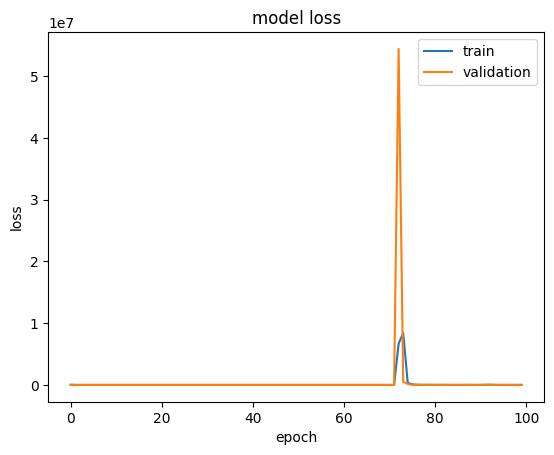

In [18]:
# training los, validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'])
plt.show()

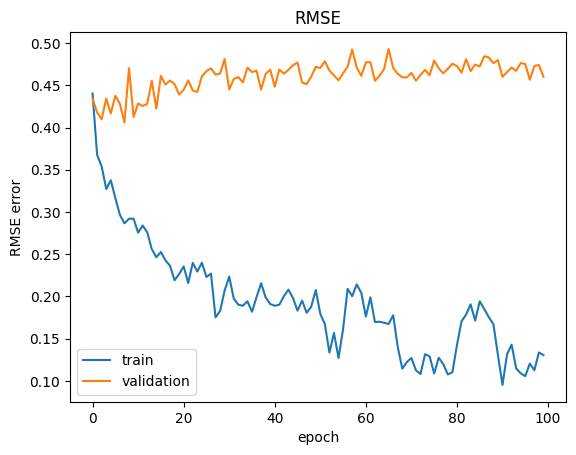

In [79]:
# # validation los
# plt.plot(history.history['val_loss'])
# plt.title('model loss')
# plt.ylabel('val loss')
# plt.xlabel('epoch')
# plt.legend(['validation'])
# plt.show()

# training los RMSE, validation loss RMSE
plt.plot(history.history['root_mean_squared_error'])
plt.plot(history.history['val_root_mean_squared_error'])
plt.title('RMSE')
plt.ylabel('RMSE error')
plt.xlabel('epoch')
plt.legend(['train', 'validation'])
plt.show()

# Model training History storing

## function defination

In [58]:
model.get_compile_config()

{'optimizer': {'module': 'keras.optimizers',
  'class_name': 'Adam',
  'config': {'name': 'adam',
   'learning_rate': 0.0010000000474974513,
   'weight_decay': None,
   'clipnorm': None,
   'global_clipnorm': None,
   'clipvalue': None,
   'use_ema': False,
   'ema_momentum': 0.99,
   'ema_overwrite_frequency': None,
   'loss_scale_factor': None,
   'gradient_accumulation_steps': None,
   'beta_1': 0.9,
   'beta_2': 0.999,
   'epsilon': 1e-07,
   'amsgrad': False},
  'registered_name': None},
 'loss': {'module': 'keras.losses',
  'class_name': 'BinaryCrossentropy',
  'config': {'name': 'binary_crossentropy',
   'reduction': 'sum_over_batch_size',
   'from_logits': True,
   'label_smoothing': 0.0,
   'axis': -1},
  'registered_name': None},
 'loss_weights': None,
 'metrics': None,
 'weighted_metrics': None,
 'run_eagerly': False,
 'steps_per_execution': 1,
 'jit_compile': False}

In [66]:
model_history = {}
# features, loss, optimizer, epoch, model.config

In [53]:
train_data.columns

Index(['Unnamed: 0', 'tweet_id', 'text_embedding', 'image_embeddings',
       'class_label'],
      dtype='object')

In [80]:
# folder_path = "/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/model_training_history.json"

# with open(folder_path, 'w') as file:
#     json.dump(model_history, file, indent=4)


In [32]:
# from math import e
def store_in_json(train_data, history, model, acc, precision, recall, f1_val):
  folder_path = "/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/model_training_history.json"
  model_history = {
      'datetime': str(pd.to_datetime('now')),
      'features': train_data.columns.tolist(),
      'history': history.history,
      'model.compile_config': model.get_compile_config(),
      'model.get_config': model.get_config(),
      'accuracy': acc,
      'precision': precision,
      'recall': recall,
      'f1_score': f1_val,

  }

  # write new data in json file
  with open(folder_path, 'r+') as file:

      try:

        file_data = json.load(file)
        # print(file_data) # commented out for cleaner output

        # Ensure file_data is a list
        if isinstance(file_data, dict):
            file_data = [file_data]

        file_data.append(model_history)
        file.seek(0)
        json.dump(file_data, file, indent=4)
        file.truncate()
        # print(file_data) # commented out for cleaner output
        print("Model history added....")

      except Exception as e:
          print(f"Error: {e}")


## call function

In [33]:
store_in_json(train_data, history, model, acc, precision, recall, f1_val)

Model history added....


# Testing History


In [104]:
# 23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.7514 - f1_score: 0.5469 - false_negatives: 118.0000 - false_positives: 65.0000 - loss: 13.8913
# [13.89132308959961, 0.751358687877655, 118.0, 65.0, 0.5468903183937073]


######################################################

# 23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.7391 - f1_score: 0.5469 - false_negatives: 108.0000 - false_positives: 84.0000 - loss: 17.7990
# [17.798973083496094, 0.739130437374115, 108.0, 84.0, 0.5468903183937073]
